In [177]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json


pd.set_option("display.max_columns", None)

In [7]:
main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

In [61]:
path_df_cleaned = 'Data/meteo_pivoted_cleaned.parquet'

df = pd.read_parquet(path_df_cleaned)

# Feature engineering

In [62]:
df.dtypes

parameter
CO2                              float64
Hr                               float64
Hr_Trockner                      float64
NO                               float64
NO2                              float64
NOx                              float64
PM2.5                            float64
PN[5-100nm]                      float64
RainDur                          float64
SO2                              float64
StrGlo                           float64
T                                float64
T_Trockner                       float64
WD                               float64
WVv                              float64
eBC2.5                           float64
year                               int32
day                               object
hour                               int32
day_of_week                        int32
month                              int32
season                            object
PM2.5_gap_too_long                 int64
PM2.5_was_interpolated             int64
NOx_ga

Zurich Airport, Switzerland: A strict night-time curfew has been in force since 29 July 2010 between 23:30 and 6:00; the time between 23:00 and 23:30 may only be used to reduce backlogs of delayed flights.[1]

Create additional imte features, to flag weekends and nighttimes

In [63]:
# create a binary feature for weekend
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
# create a nighttime feature - there are no flights during night allowed in Zurich
df['is_night'] = df['hour'].isin([0,1,2,3,4,5]).astype(int)

### Wind features

WD = Wind direction is in degrees. We'll convert it into radians and separate x and y directions.

We also create wind_x and wind_y features, which combine the direction and strentgh of the wind at each timestamp

In [64]:
# Convert degrees to radians
radians = np.deg2rad(df['WD'])

# Project onto unit circle
df['wind_dir_x'] = np.cos(radians)
df['wind_dir_y'] = np.sin(radians)

# Combine with wind speed
df['wind_x'] = df['WVv'] * np.cos(radians)
df['wind_y'] = df['WVv'] * np.sin(radians)

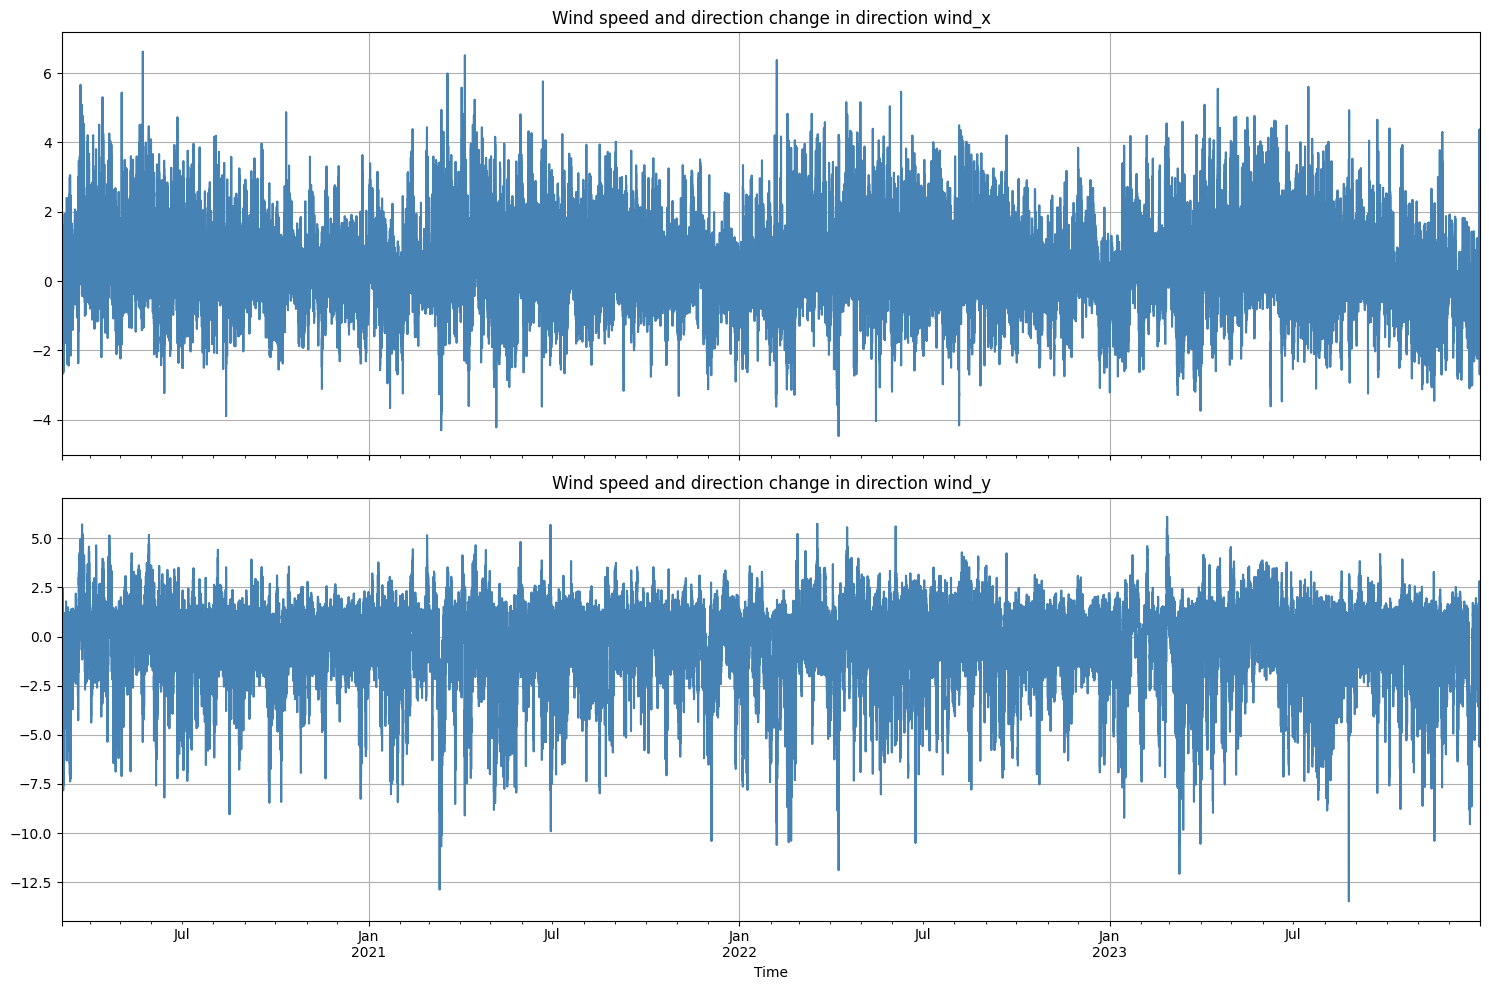

In [65]:
fig, axes = plt.subplots(nrows=len(['wind_x', 'wind_y']), ncols=1, figsize=(15,10), sharex=True)

for i, col in enumerate(['wind_x', 'wind_y']):
    df[col].plot(ax=axes[i], color=main_color)    
    axes[i].set_title(f'Wind speed and direction change in direction {col}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [66]:
# def wind_direction_sector(degrees):
#     dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
#     bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
#     return pd.cut(degrees % 360, bins=bins, labels=dirs, include_lowest=True, right=False)

# df['wind_sector'] = wind_direction_sector(df['WD'])

df = pd.get_dummies(df, columns=['wind_sector'], drop_first=False)

In [67]:
df.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'is_weekend', 'is_ni

In [68]:
pollutants_columns = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2',  'eBC2.5']
weather_columns = ['Hr', 'Hr_Trockner', 'RainDur', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'wind_dir_x', 'wind_dir_y', 'wind_x', 'wind_y']
time_features = ['year', 'day', 'hour', 'day_of_week', 'month', 'season','is_weekend', 'is_night']
potential_targets = ['PM2.5', 'NOx']
data_quality_features = ['PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated']

In [69]:
df.to_parquet('Data/meteo_cleaned_new_features.parquet')

In [70]:
df = pd.read_parquet('Data/meteo_cleaned_new_features.parquet')

In [71]:
df.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'is_weekend', 'is_ni

### Rolling averages for weather features

In [72]:
# Create rolling 1- and 24-hour averages
# use mean for temperature, humidity
# for others use median - spiky

# keep track of the rolling average features, so we can see how correlated they are with each other later
# then decide which ones to keep
avg_col = []

df_auxiliary = df.copy()

for col in weather_columns:
    df_auxiliary[col+'_1h_mean'] = df_auxiliary[col].rolling(window=6, min_periods=1).mean()
    df_auxiliary[col+'_24h_mean'] = df_auxiliary[col].rolling(window=144, min_periods=1).mean()
    avg_col = avg_col + [col+'_1h_mean', col+'_24h_mean']


for col in weather_columns:
    df_auxiliary[col+'_1h_med'] = df_auxiliary[col].rolling(window=6, min_periods=1).median()
    df_auxiliary[col+'_24h_med'] = df_auxiliary[col].rolling(window=144, min_periods=1).median()
    avg_col = avg_col + [col+'_1h_med', col+'_24h_med']

for col in weather_columns:
    df_auxiliary[col+'_1h_max'] = df_auxiliary[col].rolling(window=6, min_periods=1).max()
    avg_col = avg_col + [col+'_1h_max']

# # use max to capture gusts
# df['WVv_1h_max'] = df['WVv'].rolling(window=6, min_periods=1).max()
# avg_col = avg_col + ['WVv_1h_max']

print(avg_col)


['Hr_1h_mean', 'Hr_24h_mean', 'Hr_Trockner_1h_mean', 'Hr_Trockner_24h_mean', 'RainDur_1h_mean', 'RainDur_24h_mean', 'StrGlo_1h_mean', 'StrGlo_24h_mean', 'T_1h_mean', 'T_24h_mean', 'T_Trockner_1h_mean', 'T_Trockner_24h_mean', 'WD_1h_mean', 'WD_24h_mean', 'WVv_1h_mean', 'WVv_24h_mean', 'wind_dir_x_1h_mean', 'wind_dir_x_24h_mean', 'wind_dir_y_1h_mean', 'wind_dir_y_24h_mean', 'wind_x_1h_mean', 'wind_x_24h_mean', 'wind_y_1h_mean', 'wind_y_24h_mean', 'Hr_1h_med', 'Hr_24h_med', 'Hr_Trockner_1h_med', 'Hr_Trockner_24h_med', 'RainDur_1h_med', 'RainDur_24h_med', 'StrGlo_1h_med', 'StrGlo_24h_med', 'T_1h_med', 'T_24h_med', 'T_Trockner_1h_med', 'T_Trockner_24h_med', 'WD_1h_med', 'WD_24h_med', 'WVv_1h_med', 'WVv_24h_med', 'wind_dir_x_1h_med', 'wind_dir_x_24h_med', 'wind_dir_y_1h_med', 'wind_dir_y_24h_med', 'wind_x_1h_med', 'wind_x_24h_med', 'wind_y_1h_med', 'wind_y_24h_med', 'Hr_1h_max', 'Hr_Trockner_1h_max', 'RainDur_1h_max', 'StrGlo_1h_max', 'T_1h_max', 'T_Trockner_1h_max', 'WD_1h_max', 'WVv_1h_max

In [73]:
# check correlations
df_auxiliary[['PM2.5', 'NOx'] + avg_col].corr()

,PM2.5,NOx,Hr_1h_mean,Hr_24h_mean,Hr_Trockner_1h_mean,Hr_Trockner_24h_mean,RainDur_1h_mean,RainDur_24h_mean,StrGlo_1h_mean,StrGlo_24h_mean,T_1h_mean,T_24h_mean,T_Trockner_1h_mean,T_Trockner_24h_mean,WD_1h_mean,WD_24h_mean,WVv_1h_mean,WVv_24h_mean,wind_dir_x_1h_mean,wind_dir_x_24h_mean,wind_dir_y_1h_mean,wind_dir_y_24h_mean,wind_x_1h_mean,wind_x_24h_mean,wind_y_1h_mean,wind_y_24h_mean,Hr_1h_med,Hr_24h_med,Hr_Trockner_1h_med,Hr_Trockner_24h_med,RainDur_1h_med,RainDur_24h_med,StrGlo_1h_med,StrGlo_24h_med,T_1h_med,T_24h_med,T_Trockner_1h_med,T_Trockner_24h_med,WD_1h_med,WD_24h_med,WVv_1h_med,WVv_24h_med,wind_dir_x_1h_med,wind_dir_x_24h_med,wind_dir_y_1h_med,wind_dir_y_24h_med,wind_x_1h_med,wind_x_24h_med,wind_y_1h_med,wind_y_24h_med,Hr_1h_max,Hr_Trockner_1h_max,RainDur_1h_max,StrGlo_1h_max,T_1h_max,T_Trockner_1h_max,WD_1h_max,WVv_1h_max,wind_dir_x_1h_max,wind_dir_y_1h_max,wind_x_1h_max,wind_y_1h_max
PM2.5,1.000000,0.356232,0.039261,-0.009372,-0.210767,-0.246981,-0.176029,-0.286951,-0.003893,-0.021221,-0.197357,-0.210854,0.017618,0.019048,-0.144948,-0.292934,-0.252789,-0.336764,0.165781,0.287821,0.183518,0.327982,0.134722,0.237846,0.238155,0.342598,0.039292,-0.002113,-0.210694,-0.243530,-0.159881,-0.095095,-0.002673,-0.088236,-0.197272,-0.215633,0.018838,0.023274,-0.134936,-0.287073,-0.249589,-0.286256,0.162205,0.263668,0.175670,0.327584,0.133813,0.235508,0.235932,0.325179,0.034600,-0.210500,-0.200718,-0.021415,-0.192186,0.052886,-0.073564,-0.260451,0.203406,0.204058,0.087061,0.217241
NOx,0.356232,1.000000,0.289497,0.246605,-0.226383,-0.257362,0.000112,-0.041531,-0.162835,-0.278145,-0.361351,-0.342870,-0.130566,-0.129211,0.100464,0.018431,-0.279286,-0.286839,-0.090831,-0.108700,-0.009332,0.069504,-0.146352,-0.158424,0.016877,0.046301,0.289431,0.255522,-0.226480,-0.256103,0.001810,0.025666,-0.162297,-0.274690,-0.361559,-0.352764,-0.126523,-0.122801,0.105242,-0.013954,-0.278366,-0.261089,-0.088447,-0.120066,-0.012685,0.110242,-0.144636,-0.139694,0.017439,0.052779,0.291736,-0.221544,-0.016211,-0.162519,-0.354201,-0.077125,0.121737,-0.273612,0.003187,0.041693,-0.189779,-0.006965
Hr_1h_mean,0.039261,0.289497,1.000000,0.660951,0.039371,-0.002899,0.304117,0.340583,-0.597558,-0.570971,-0.545313,-0.296972,-0.251099,-0.174697,-0.040141,0.149790,-0.370596,-0.140689,-0.179122,-0.176461,0.122545,-0.120955,-0.277127,-0.229006,0.070715,-0.105968,0.999560,0.632281,0.039603,-0.009962,0.285961,0.165728,-0.595392,-0.450806,-0.545703,-0.299847,-0.245147,-0.163586,-0.039071,0.152228,-0.371263,-0.119410,-0.175214,-0.158458,0.126960,-0.119451,-0.276560,-0.194312,0.072787,-0.116645,0.995438,0.038396,0.310375,-0.592684,-0.550665,-0.186827,0.011043,-0.364199,-0.092748,0.137874,-0.339652,0.025318
Hr_24h_mean,-0.009372,0.246605,0.660951,1.000000,-0.044920,-0.011201,0.197453,0.451661,-0.295186,-0.783523,-0.423497,-0.453447,-0.232827,-0.253012,0.075845,0.170088,-0.130400,-0.221166,-0.138159,-0.229885,-0.062516,-0.133968,-0.184367,-0.300137,-0.053362,-0.107057,0.659900,0.976653,-0.044923,-0.014687,0.182745,0.244723,-0.294310,-0.608599,-0.423471,-0.463447,-0.228971,-0.242334,0.070405,0.158786,-0.130703,-0.199795,-0.136388,-0.205983,-0.057754,-0.110485,-0.183060,-0.250881,-0.052792,-0.115833,0.654736,-0.041147,0.203304,-0.281932,-0.430819,-0.179206,0.067694,-0.128281,-0.110139,-0.051082,-0.207098,-0.074579
Hr_Trockner_1h_mean,-0.210767,-0.226383,0.039371,-0.044920,1.000000,0.964240,0.055681,0.020132,0.140296,0.363135,0.739540,0.810153,0.023706,0.053882,0.067945,0.104305,-0.064477,-0.123304,-0.033964,-0.051638,-0.027191,-0.029509,-0.043404,-0.070610,-0.044898,-0.049470,0.039741,-0.026844,0.999853,0.960376,0.049841,-0.015444,0.138246,0.321180,0.739220,0.800567,0.015486,0.025936,0.063802,0.059046,-0.065564,-0.157193,-0.029980,-0.036390,-0.025689,-0.016374,-0.043024,-0.079747,-0.043394,-0.020757,0.050092,0.998372,0.076053,0.153914,0.736141,-0.117032,0.095204,-0.044653,0.008875,0.002967,-0.024187,-0.028296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [74]:
for var in weather_columns:
    avg_cols_names =[f'{var}{x}' for x in ['_1h_mean', '_1h_med','_1h_max', '_24h_mean', '_24h_med', ]]
    # print(avg_cols_names)
    print(f"{var}: corr. between different averages:")
    display(df_auxiliary[avg_cols_names+['PM2.5','NOx']].corr())

Hr: corr. between different averages:


,Hr_1h_mean,Hr_1h_med,Hr_1h_max,Hr_24h_mean,Hr_24h_med,PM2.5,NOx
Hr_1h_mean,1.000000,0.999560,0.995438,0.660951,0.632281,0.039261,0.289497
Hr_1h_med,0.999560,1.000000,0.994319,0.659900,0.631258,0.039292,0.289431
Hr_1h_max,0.995438,0.994319,1.000000,0.654736,0.627372,0.034600,0.291736
Hr_24h_mean,0.660951,0.659900,0.654736,1.000000,0.976653,-0.009372,0.246605
Hr_24h_med,0.632281,0.631258,0.627372,0.976653,1.000000,-0.002113,0.255522
PM2.5,0.039261,0.039292,0.034600,-0.009372,-0.002113,1.000000,0.356232
NOx,0.289497,0.289431,0.291736,0.246605,0.255522,0.356232,1.000000


Hr_Trockner: corr. between different averages:


,Hr_Trockner_1h_mean,Hr_Trockner_1h_med,Hr_Trockner_1h_max,Hr_Trockner_24h_mean,Hr_Trockner_24h_med,PM2.5,NOx
Hr_Trockner_1h_mean,1.000000,0.999853,0.998372,0.964240,0.960376,-0.210767,-0.226383
Hr_Trockner_1h_med,0.999853,1.000000,0.997863,0.963967,0.960102,-0.210694,-0.226480
Hr_Trockner_1h_max,0.998372,0.997863,1.000000,0.963129,0.959313,-0.210500,-0.221544
Hr_Trockner_24h_mean,0.964240,0.963967,0.963129,1.000000,0.998168,-0.246981,-0.257362
Hr_Trockner_24h_med,0.960376,0.960102,0.959313,0.998168,1.000000,-0.243530,-0.256103
PM2.5,-0.210767,-0.210694,-0.210500,-0.246981,-0.243530,1.000000,0.356232
NOx,-0.226383,-0.226480,-0.221544,-0.257362,-0.256103,0.356232,1.000000


RainDur: corr. between different averages:


...

,wind_dir_y_1h_mean,wind_dir_y_1h_med,wind_dir_y_1h_max,wind_dir_y_24h_mean,wind_dir_y_24h_med,PM2.5,NOx
wind_dir_y_1h_mean,1.000000,0.990150,0.916576,0.473591,0.417543,0.183518,-0.009332
wind_dir_y_1h_med,0.990150,1.000000,0.890626,0.457382,0.403670,0.175670,-0.012685
wind_dir_y_1h_max,0.916576,0.890626,1.000000,0.481393,0.425948,0.204058,0.041693
wind_dir_y_24h_mean,0.473591,0.457382,0.481393,1.000000,0.921626,0.327982,0.069504
wind_dir_y_24h_med,0.417543,0.403670,0.425948,0.921626,1.000000,0.327584,0.110242
PM2.5,0.183518,0.175670,0.204058,0.327982,0.327584,1.000000,0.356232
NOx,-0.009332,-0.012685,0.041693,0.069504,0.110242,0.356232,1.000000


wind_x: corr. between different averages:


,wind_x_1h_mean,wind_x_1h_med,wind_x_1h_max,wind_x_24h_mean,wind_x_24h_med,PM2.5,NOx
wind_x_1h_mean,1.000000,0.993454,0.948358,0.612577,0.586800,0.134722,-0.146352
wind_x_1h_med,0.993454,1.000000,0.929022,0.606701,0.581143,0.133813,-0.144636
wind_x_1h_max,0.948358,0.929022,1.000000,0.561141,0.534140,0.087061,-0.189779
wind_x_24h_mean,0.612577,0.606701,0.561141,1.000000,0.979009,0.237846,-0.158424
wind_x_24h_med,0.586800,0.581143,0.534140,0.979009,1.000000,0.235508,-0.139694
PM2.5,0.134722,0.133813,0.087061,0.237846,0.235508,1.000000,0.356232
NOx,-0.146352,-0.144636,-0.189779,-0.158424,-0.139694,0.356232,1.000000


wind_y: corr. between different averages:


,wind_y_1h_mean,wind_y_1h_med,wind_y_1h_max,wind_y_24h_mean,wind_y_24h_med,PM2.5,NOx
wind_y_1h_mean,1.000000,0.997158,0.974049,0.605704,0.566137,0.238155,0.016877
wind_y_1h_med,0.997158,1.000000,0.968095,0.601326,0.562102,0.235932,0.017439
wind_y_1h_max,0.974049,0.968095,1.000000,0.601459,0.564681,0.217241,-0.006965
wind_y_24h_mean,0.605704,0.601326,0.601459,1.000000,0.973226,0.342598,0.046301
wind_y_24h_med,0.566137,0.562102,0.564681,0.973226,1.000000,0.325179,0.052779
PM2.5,0.238155,0.235932,0.217241,0.342598,0.325179,1.000000,0.356232
NOx,0.016877,0.017439,-0.006965,0.046301,0.052779,0.356232,1.000000


In [76]:
display(df[pollutants_columns].corr())

,CO2,NO,NO2,NOx,PM2.5,PN[5-100nm],SO2,eBC2.5
CO2,1.000000,0.512286,0.518298,0.580022,0.325410,-0.058671,0.097459,0.605775
NO,0.512286,1.000000,0.567987,0.917476,0.311103,0.147947,0.476854,0.739396
NO2,0.518298,0.567987,1.000000,0.848511,0.323196,0.254060,0.480416,0.684502
NOx,0.580022,0.917476,0.848511,1.000000,0.356232,0.217266,0.538096,0.806215
PM2.5,0.325410,0.311103,0.323196,0.356232,1.000000,-0.045094,0.395234,0.602155
PN[5-100nm],-0.058671,0.147947,0.254060,0.217266,-0.045094,1.000000,0.326156,0.130517
SO2,0.097459,0.476854,0.480416,0.538096,0.395234,0.326156,1.000000,0.537615
eBC2.5,0.605775,0.739396,0.684502,0.806215,0.602155,0.130517,0.537615,1.000000


In [77]:
df_model_NOx = df.drop(columns=['CO2', 'NO', 'NO2', 'PN[5-100nm]', 'SO2',  'eBC2.5'])

In [78]:
# Create rolling 1- and 24-hour averages
# use mean for temperature, humidity
# for others use median - spiky

# keep track of the rolling average features, so we can see how correlated they are with each other later
# then decide which ones to keep
avg_col = []


# 1h mean
for col in ['T', 'T_Trockner', 'WVv', 'wind_dir_x', 'wind_y']:
    df_model_NOx[col+'_1h_mean'] = df_model_NOx[col].rolling(window=6, min_periods=1).mean()
    avg_col = avg_col + [col+'_1h_mean']

# 1h meadian
for col in ['Hr_Trockner']:
    df_model_NOx[col+'_1h_med'] = df_model_NOx[col].rolling(window=6, min_periods=1).median()
    avg_col = avg_col + [col+'_1h_med']

# 1h max
for col in ['Hr', 'RainDur', 'StrGlo', 'WD', 'wind_dir_y', 'wind_x']:
    df_model_NOx[col+'_1h_max'] = df_model_NOx[col].rolling(window=6, min_periods=1).max()
    avg_col = avg_col + [col+'_1h_max']

# 24h mean
for col in ['Hr_Trockner', 'RainDur', 'T_Trockner', 'WD', 'WVv', 'wind_x']:
    df_model_NOx[col+'_24h_mean'] = df_model_NOx[col].rolling(window=144, min_periods=1).mean()
    avg_col = avg_col + [col+'_24h_mean']

# 24h median
for col in ['StrGlo', 'T', 'wind_dir_x', 'wind_dir_y', 'wind_y']:
    df_model_NOx[col+'_24h_med'] = df_model_NOx[col].rolling(window=144, min_periods=1).median()
    avg_col = avg_col + [col+'_24h_med']


print(avg_col)


['T_1h_mean', 'T_Trockner_1h_mean', 'WVv_1h_mean', 'wind_dir_x_1h_mean', 'wind_y_1h_mean', 'Hr_Trockner_1h_med', 'Hr_1h_max', 'RainDur_1h_max', 'StrGlo_1h_max', 'WD_1h_max', 'wind_dir_y_1h_max', 'wind_x_1h_max', 'Hr_Trockner_24h_mean', 'RainDur_24h_mean', 'T_Trockner_24h_mean', 'WD_24h_mean', 'WVv_24h_mean', 'wind_x_24h_mean', 'StrGlo_24h_med', 'T_24h_med', 'wind_dir_x_24h_med', 'wind_dir_y_24h_med', 'wind_y_24h_med']


In [79]:
df_model_NOx.select_dtypes(include='object').columns


Index(['day', 'season'], dtype='object')

In [80]:
df_model_NOx = pd.get_dummies(df_model_NOx, columns=['season'], drop_first=False)

In [81]:
df_model_NOx['dayofyear'] = pd.to_datetime(df_model_NOx['day']).dt.dayofyear
df_model_NOx = df_model_NOx.drop(columns='day')
display(df_model_NOx.columns)

Index(['Hr', 'Hr_Trockner', 'NOx', 'PM2.5', 'RainDur', 'StrGlo', 'T',
       'T_Trockner', 'WD', 'WVv', 'year', 'hour', 'day_of_week', 'month',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'is_weekend', 'is_night', 'wind_dir_x',
       'wind_dir_y', 'wind_x', 'wind_y', 'wind_sector_N'

In [89]:
df_model_NOx = df_model_NOx.drop(columns='PM2.5')

In [90]:
df_model_NOx.dtypes.value_counts()


float64    36
int64      30
bool       12
int32       5
Name: count, dtype: int64

In [91]:
df_model_NOx.to_parquet('Data/df_model_NOx_cleaned.parquet')

In [92]:
target_col = 'NOx'

# Baseline - training only on weather data

## Train a random forest model

MAE: 4.456860005164678
RMSE: 8.065385857452656
R²: 0.4529911120483193


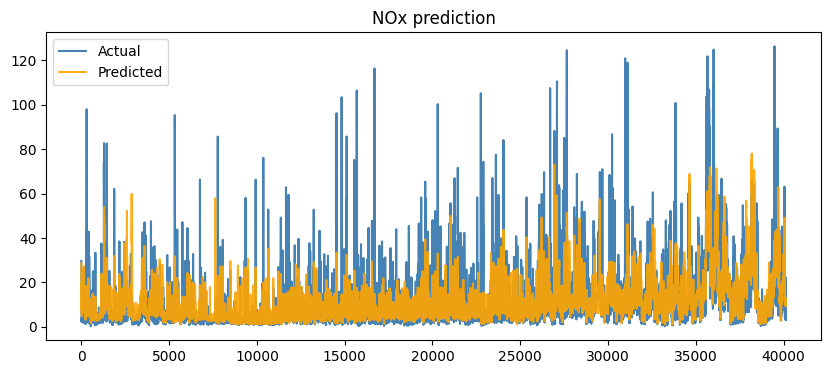

In [178]:
# for the random forest, we have to remove missing values
df_model_NOx = pd.read_parquet('Data/df_model_NOx_cleaned.parquet')
df_model_NOx = df_model_NOx.dropna()

from sklearn.model_selection import train_test_split

X = df_model_NOx.drop(columns=target_col)
y = df_model_NOx[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # no shuffle for time series
)

from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_RF.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_RF.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

In [176]:
joblib.dump(model_RF, 'models/RF_NOx_weather_only.pkl')


['models/RF_NOx_weather_only.pkl']

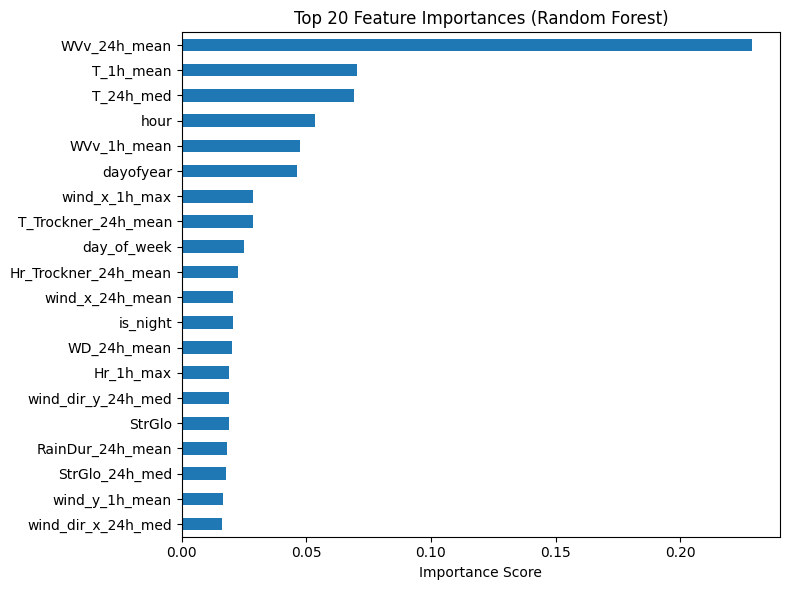

In [179]:
# Create a Series of importances with feature names
importances = pd.Series(model_RF.feature_importances_, index=X_train.columns)

# Sort and show top 20
top_features = importances.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()  # highest at the top
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


/Users/martadujella/Code/DataProjects/Sika/ParticlesMeasurmentKloten/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


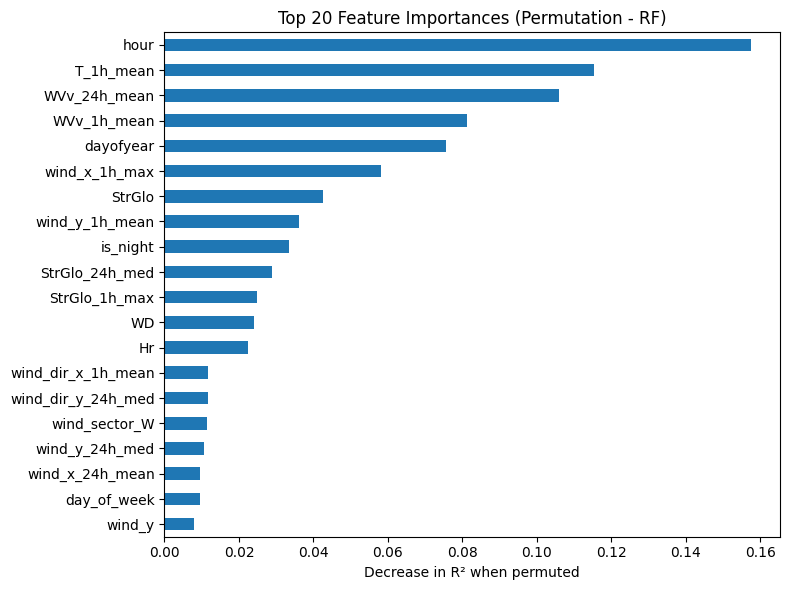

In [183]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_RF, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - RF)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



In [184]:
import json
import pandas as pd

# Save metrics
metrics = {
    "r2": r2_score(y_test, y_pred),
    "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae": mean_absolute_error(y_test, y_pred)
}
model_type ='RF'
with open(f"results/{model_type}_{target_col}_weather_only_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save predicted vs actual
# pred_df = pd.DataFrame({
#     "y_true": y_test.values,
#     "y_pred": y_pred
# })
# pred_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_predictions.parquet")
pd.DataFrame({'y_test': y_test}).to_parquet(f'results/{model_type}_{target_col}_weather_only_y_test.parquet')
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred}).to_parquet(f'results/{model_type}_{target_col}_weather_only_predictions_.parquet')


# Save top features
top_features_df = top_features.to_frame()
top_features_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_features.parquet")

top_perm = perm_importances.to_frame()
top_perm.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_perm.parquet")



## Gradient boost - HGBR

In [185]:
df_model_NOx = pd.read_parquet('Data/df_model_NOx_cleaned.parquet')

In [186]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_NOx = df_model_NOx.dropna(subset=['NOx'])

X = df_model_NOx.drop(columns=target_col)
y = df_model_NOx[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR.fit(X_train, y_train)

# Predict
y_pred = model_HGBR.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 3.945
RMSE: 7.225
R²: 0.561


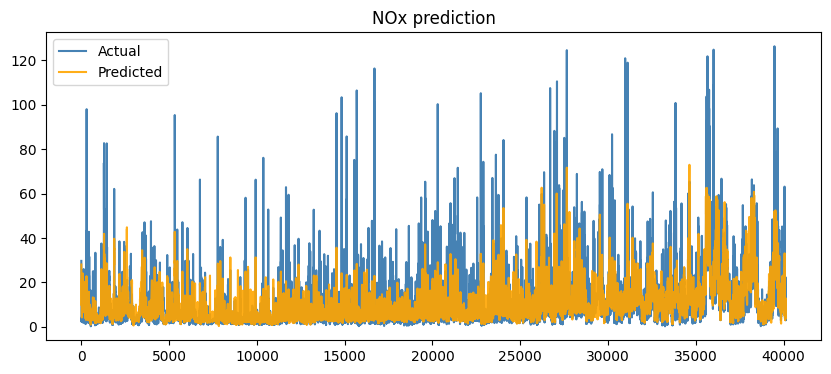

In [187]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

In [188]:
joblib.dump(model_HGBR, 'models/HGBR_NOx_weather_only.pkl')


['models/HGBR_NOx_weather_only.pkl']

how much worse the model performs when each feature is shuffled.



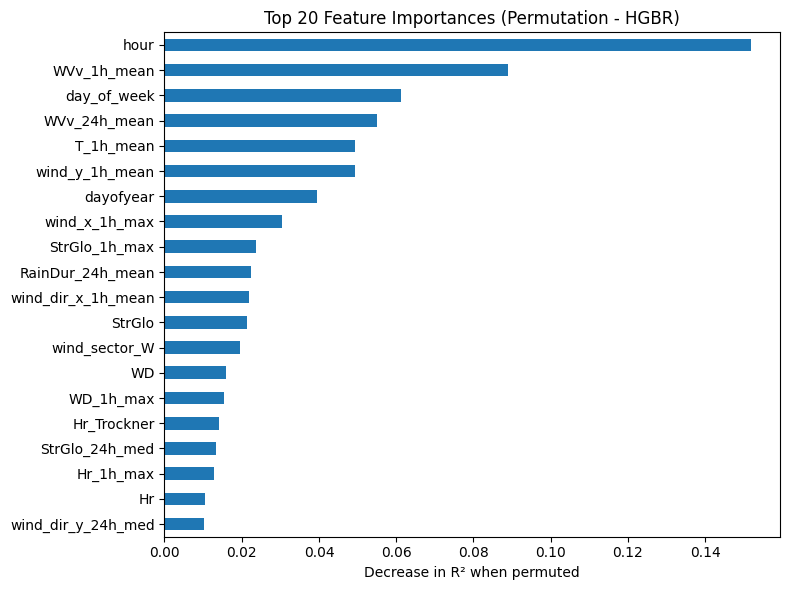

In [189]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



In [190]:
import json
import pandas as pd

# Save metrics
metrics = {
    "r2": r2_score(y_test, y_pred),
    "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae": mean_absolute_error(y_test, y_pred)
}
model_type ='HGBR'
with open(f"results/{model_type}_{target_col}_weather_only_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save predicted vs actual
# pred_df = pd.DataFrame({
#     "y_true": y_test.values,
#     "y_pred": y_pred
# })
# pred_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_predictions.parquet")
pd.DataFrame({'y_test': y_test}).to_parquet(f'results/{model_type}_{target_col}_weather_only_y_test.parquet')
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred}).to_parquet(f'results/{model_type}_{target_col}_weather_only_predictions_.parquet')


# # Save top features
# top_features_df = top_features.to_frame()
# top_features_df.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_features.parquet")

top_perm = perm_importances.to_frame()
top_perm.to_parquet(f"results/{model_type}_{target_col}_weather_only_top_perm.parquet")



## Using lagged features

In [121]:
path_df_model_NOx = 'Data/df_model_NOx_cleaned.parquet'
df_model_NOx = pd.read_parquet(path_df_model_NOx)

In [122]:
df_model_NOx['NOx_lag_1'] = df_model_NOx['NOx'].shift(1)
df_model_NOx['NOx_lag_6'] = df_model_NOx['NOx'].shift(6)
df_model_NOx['NOx_lag_12'] = df_model_NOx['NOx'].shift(12)
df_model_NOx['NOx_roll_1h'] = df_model_NOx['NOx'].shift(1).rolling(window=6, min_periods=1).mean()


In [123]:
df_model_NOx = df_model_NOx.dropna(subset=['NOx', 'NOx_lag_1', 'NOx_lag_6', 'NOx_lag_12', 'NOx_roll_1h'])


In [124]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_NOx = df_model_NOx.dropna(subset=[target_col])

X = df_model_NOx.drop(columns=target_col)
y = df_model_NOx[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR_lagged = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR_lagged.fit(X_train, y_train)

# Predict
y_pred = model_HGBR_lagged.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 1.804
RMSE: 3.817
R²: 0.877


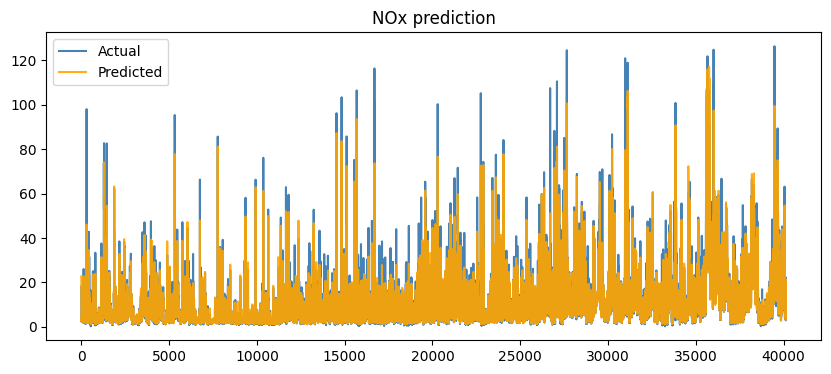

In [125]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

how much worse the model performs when each feature is shuffled.



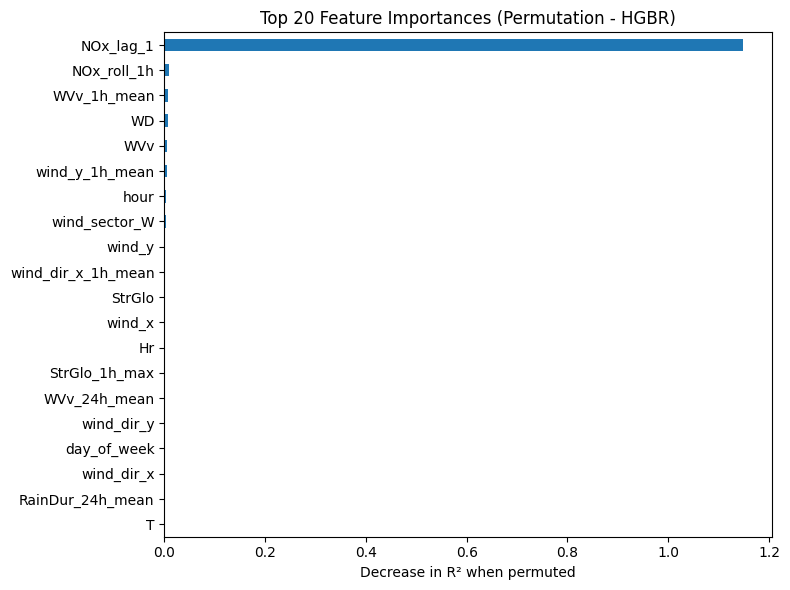

In [126]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR_lagged, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



## Lagged model, with only NOx data

In [ ]:
path_df_model_NOx = 'Data/df_model_NOx_cleaned.parquet'
df_model_NOx = pd.read_parquet(path_df_model_NOx)

In [128]:
df_model_NOx['NOx_lag_1'] = df_model_NOx['NOx'].shift(1)
df_model_NOx['NOx_lag_6'] = df_model_NOx['NOx'].shift(6)
df_model_NOx['NOx_lag_12'] = df_model_NOx['NOx'].shift(12)
df_model_NOx['NOx_roll_1h'] = df_model_NOx['NOx'].shift(1).rolling(window=6, min_periods=1).mean()


In [129]:
df_model_NOx = df_model_NOx.dropna(subset=['NOx', 'NOx_lag_1', 'NOx_lag_6', 'NOx_lag_12', 'NOx_roll_1h'])


In [130]:
df_model_NOx_lagged_only = df_model_NOx[['NOx', 'NOx_lag_1', 'NOx_lag_6', 'NOx_lag_12', 'NOx_roll_1h']]

In [132]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop missing values just for target (not features — model handles those)
df_model_NOx_lagged_only = df_model_NOx_lagged_only.dropna(subset=[target_col])

X = df_model_NOx_lagged_only.drop(columns=target_col)
y = df_model_NOx_lagged_only[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_HGBR_lagged_only = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_HGBR_lagged_only.fit(X_train, y_train)

# Predict
y_pred = model_HGBR_lagged_only.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 1.929
RMSE: 4.086
R²: 0.860


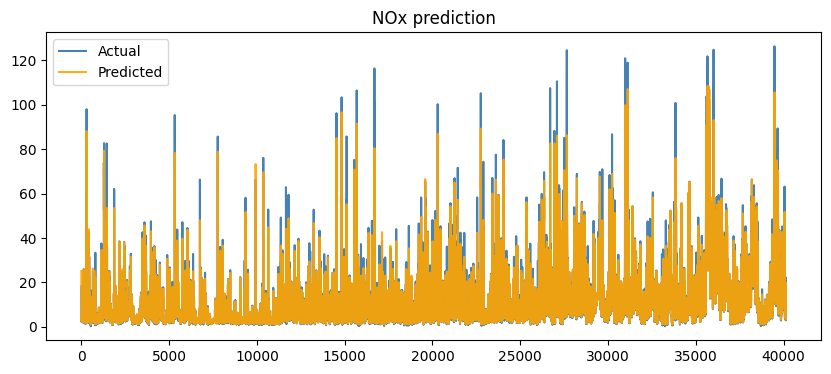

In [133]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.9)
plt.legend()
plt.title(f'{target_col} prediction')
plt.show()

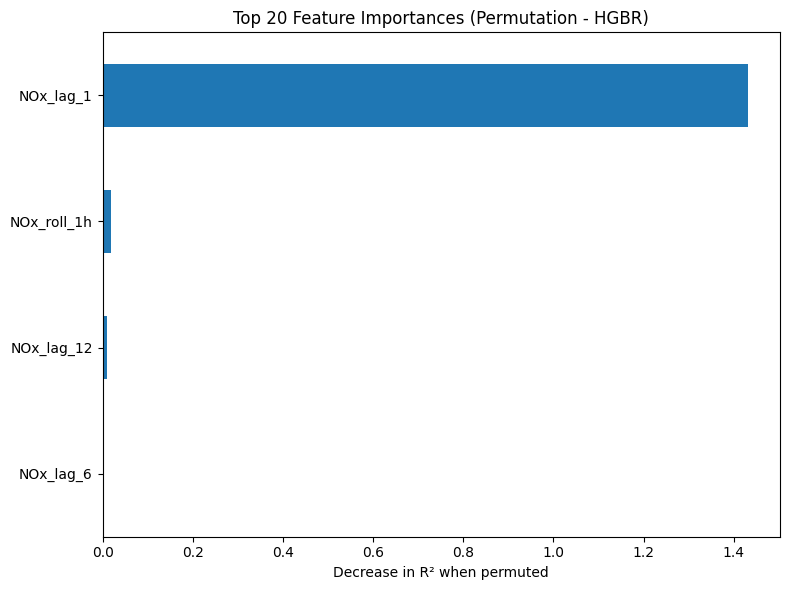

In [134]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_HGBR_lagged_only, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

import pandas as pd
import matplotlib.pyplot as plt

# Create a Series from the importances
perm_importances = pd.Series(result.importances_mean, index=X_test.columns)

# Plot top 20
top_perm = perm_importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Permutation - HGBR)")
plt.xlabel("Decrease in R² when permuted")
plt.tight_layout()
plt.show()



# Understanding pollution drivers

In [135]:
df_model_NOx = pd.read_parquet(path_df_model_NOx)

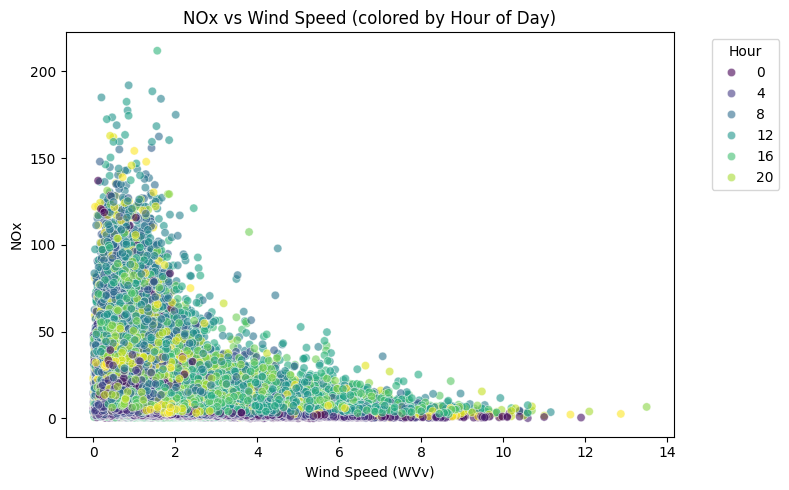

In [137]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model_NOx, x='WVv', y='NOx', hue='hour', palette='viridis', alpha=0.6)
plt.title("NOx vs Wind Speed (colored by Hour of Day)")
plt.xlabel("Wind Speed (WVv)")
plt.ylabel("NOx")
plt.legend(title='Hour', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/pp/55r76hw53w51fgc71j966cfm0000gn/T/ipykernel_14554/716404436.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_model_NOx, x='hour', y='NOx', hue='season', ci='sd')


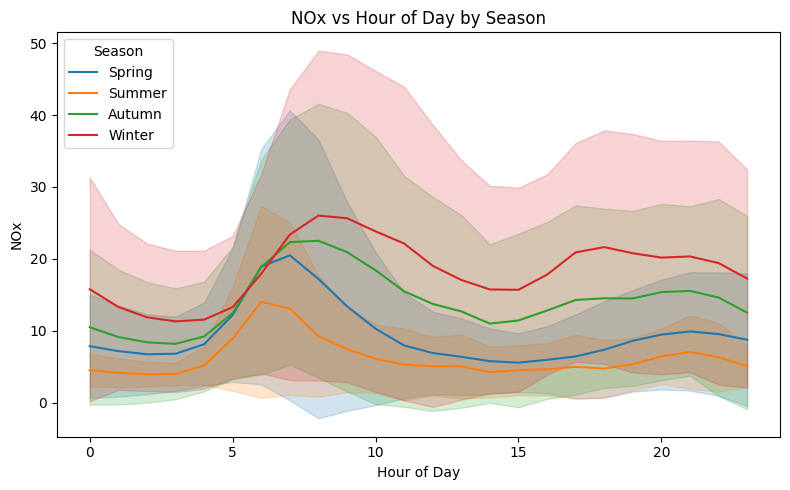

In [139]:
df_model_NOx = pd.read_parquet('Data/meteo_cleaned_new_features.parquet')
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_model_NOx, x='hour', y='NOx', hue='season', ci='sd')
plt.title("NOx vs Hour of Day by Season")
plt.xlabel("Hour of Day")
plt.ylabel("NOx")
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [142]:
df_model_NOx.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'is_weekend', 'is_ni

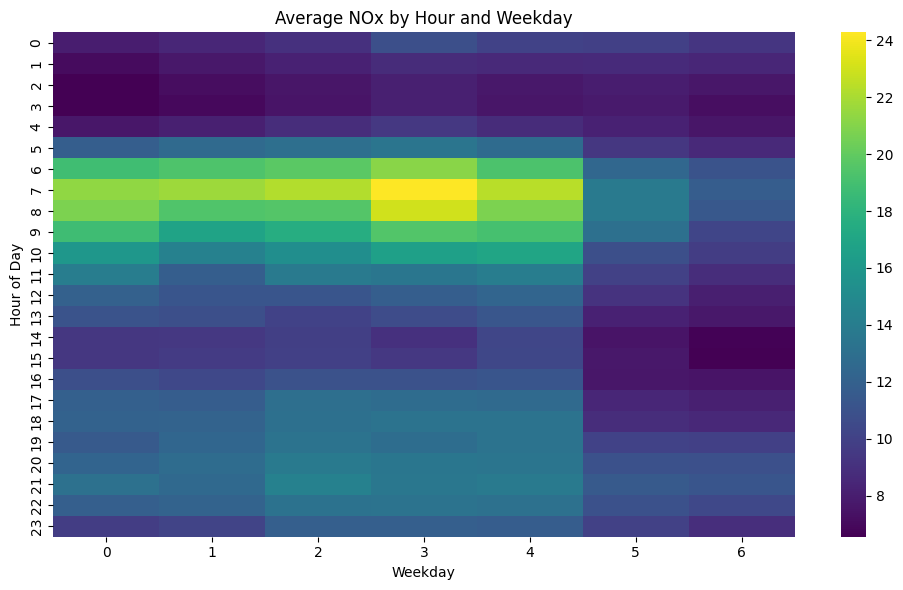

In [143]:
# Create pivot table
pivot = df_model_NOx.pivot_table(index='hour', columns='day_of_week', values='NOx', aggfunc='mean')

# Optional: reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[day_order] if all(day in pivot.columns for day in day_order) else pivot

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='viridis', annot=False, fmt=".1f")
plt.title("Average NOx by Hour and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()


In [144]:
df_cleaned = pd.read_parquet(path_df_cleaned)
df_cleaned.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'wind_sector'],
    

/var/folders/pp/55r76hw53w51fgc71j966cfm0000gn/T/ipykernel_14554/1323937619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pollutant_means = df_cleaned.groupby('wind_sector')['NOx'].mean()


<Axes: title={'center': 'Avg NOx by Wind Direction'}, xlabel='wind_sector'>

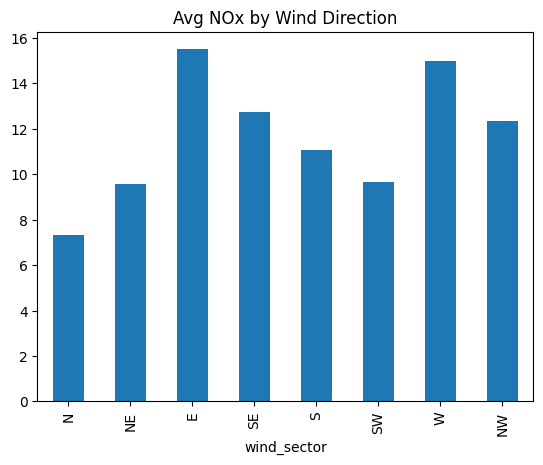

In [145]:

pollutant_means = df_cleaned.groupby('wind_sector')['NOx'].mean()
pollutant_means.plot(kind='bar', title='Avg NOx by Wind Direction')

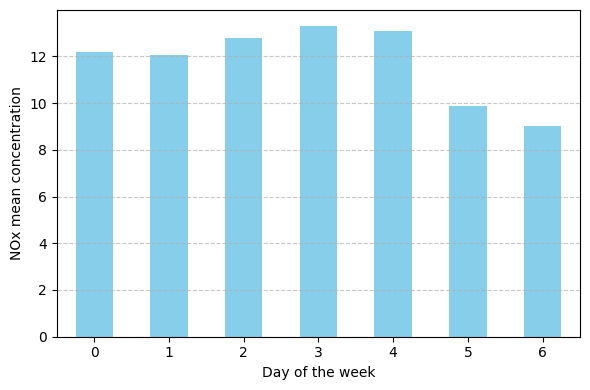

In [152]:
mean_by_day = df_cleaned.groupby([df_cleaned.index.weekday])['NOx'].mean()
mean_by_day.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.xlabel('Day of the week')
plt.ylabel('NOx mean concentration')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

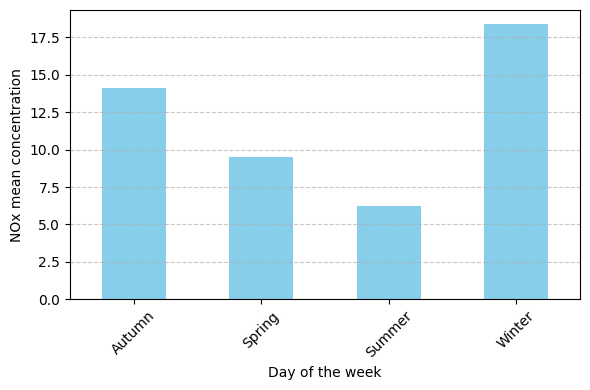

In [149]:
mean_by_season = df_cleaned.groupby([df_cleaned['season']])['NOx'].mean()
mean_by_season.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.xlabel('Day of the week')
plt.ylabel('NOx mean concentration')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [161]:
df_cleaned['day_of_year'] = df_cleaned.index.day_of_year

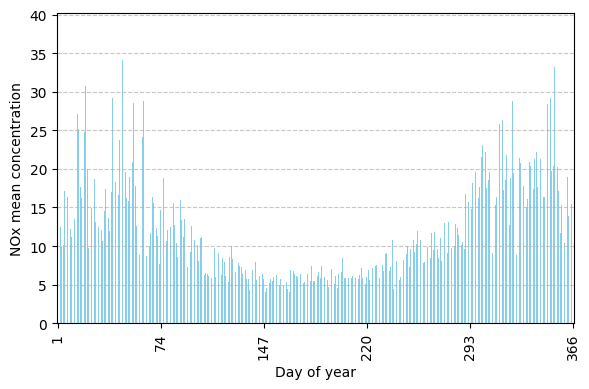

In [163]:
mean_by_dayofyear = df_cleaned.groupby([df_cleaned['day_of_year']])['NOx'].mean()
mean_by_dayofyear.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.xlabel('Day of year')
plt.ylabel('NOx mean concentration')
tick_positions = range(0, len(mean_by_dayofyear), 73)
tick_labels = [mean_by_dayofyear.index[i] for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=90)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## LightGBM

In [109]:
df_model_NOx = pd.read_parquet('Data/df_model_NOx_cleaned.parquet')

df_model_NOx = df_model_NOx.dropna(subset=[target_col])

X = df_model_NOx.drop(columns=target_col)
y = df_model_NOx[target_col]

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

import lightgbm as lgb

model_LGBM = lgb.LGBMRegressor()
model_LGBM.fit(X_train, y_train)

# Predict
y_pred = model_LGBM.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


importances = pd.Series(model.feature_importances_, index=X_train.columns)

OSError: dlopen(/Users/martadujella/Code/DataProjects/Sika/ParticlesMeasurmentKloten/.venv/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/martadujella/Code/DataProjects/Sika/ParticlesMeasurmentKloten/.venv/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no suc